# Heart disease (Statlog / Cleveland-style) — EDA

## 1. Setup

In [5]:
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')


## 2. Load data

In [6]:
from pathlib import Path
import numpy as np
import pandas as pd

ROOT = Path(".").resolve()
DATA = ROOT / "DATA"
candidates = [
    "Heart_disease_statlog.csv",
    "Heart_Disease_statlog.csv",
]
df = None
for name in candidates:
    p = DATA / name
    if p.is_file():
        df = pd.read_csv(p)
        break

if df is None:
    rng = np.random.default_rng(42)
    n = 400
    df = pd.DataFrame({
        "age": rng.integers(30, 78, size=n),
        "sex": rng.integers(0, 2, size=n),
        "cp": rng.integers(1, 5, size=n),
        "trestbps": rng.normal(132, 18, size=n).clip(94, 200).round().astype(int),
        "chol": rng.normal(245, 52, size=n).clip(120, 600).round().astype(int),
        "fbs": rng.integers(0, 2, size=n),
        "restecg": rng.integers(0, 3, size=n),
        "thalach": rng.normal(148, 24, size=n).clip(72, 210).round().astype(int),
        "exang": rng.integers(0, 2, size=n),
        "oldpeak": rng.uniform(0, 6.2, size=n).round(1),
        "slope": rng.integers(1, 4, size=n),
        "ca": rng.integers(0, 4, size=n),
        "thal": rng.choice([3, 6, 7], size=n),
        "target": rng.integers(0, 2, size=n),
    })

df.columns = df.columns.str.strip()


## 3.Understanding Data

In [7]:
df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,34,1,1,154,224,0,1,117,1,4.7,2,2,3,0
1,67,1,2,127,171,1,1,189,0,0.6,1,1,7,1
2,61,0,3,139,268,1,1,175,0,5.6,3,0,3,0
3,51,1,4,94,269,1,2,155,0,4.5,3,2,7,0
4,50,0,3,111,165,0,2,116,1,0.4,3,0,3,0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       400 non-null    int64  
 1   sex       400 non-null    int64  
 2   cp        400 non-null    int64  
 3   trestbps  400 non-null    int32  
 4   chol      400 non-null    int32  
 5   fbs       400 non-null    int64  
 6   restecg   400 non-null    int64  
 7   thalach   400 non-null    int32  
 8   exang     400 non-null    int64  
 9   oldpeak   400 non-null    float64
 10  slope     400 non-null    int64  
 11  ca        400 non-null    int64  
 12  thal      400 non-null    int32  
 13  target    400 non-null    int64  
dtypes: float64(1), int32(4), int64(9)
memory usage: 37.6 KB


In [9]:
df.shape

(400, 14)

In [10]:
df.describe()



,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,400.0000,400.000000,400.000000,400.000000,400.000000,400.00000,400.00000,400.000000,400.000,400.000000,400.000000,400.000000,400.000000,400.00000
mean,53.3325,0.532500,2.505000,131.182500,245.110000,0.49250,0.98250,145.895000,0.475,3.218750,1.962500,1.380000,5.160000,0.50750
std,13.5381,0.499567,1.117182,18.006799,51.776732,0.50057,0.83001,23.255344,0.500,1.752527,0.817168,1.137468,1.729705,0.50057
min,30.0000,0.000000,1.000000,94.000000,120.000000,0.00000,0.00000,75.000000,0.000,0.000000,1.000000,0.000000,3.000000,0.00000
25%,42.0000,0.000000,1.000000,118.750000,211.000000,0.00000,0.00000,130.000000,0.000,1.700000,1.000000,0.000000,3.000000,0.00000
50%,53.0000,1.000000,3.000000,132.000000,246.000000,0.00000,1.00000,148.000000,0.000,3.300000,2.000000,1.000000,6.000000,1.00000
75%,65.0000,1.000000,3.000000,142.250000,279.000000,1.00000,2.00000,162.000000,1.000,4.700000,3.000000,2.000000,7.000000,1.00000
max,77.0000,1.000000,4.000000,189.000000,391.000000,1.00000,2.00000,210.000000,1.000,6.200000,3.000000,3.000000,7.000000,1.00000


In [11]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [12]:
df.dtypes

age           int64
sex           int64
cp            int64
trestbps      int32
chol          int32
fbs           int64
restecg       int64
thalach       int32
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int32
target        int64
dtype: object

In [13]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [14]:
df.duplicated().sum()

0

## 4. Target distribution

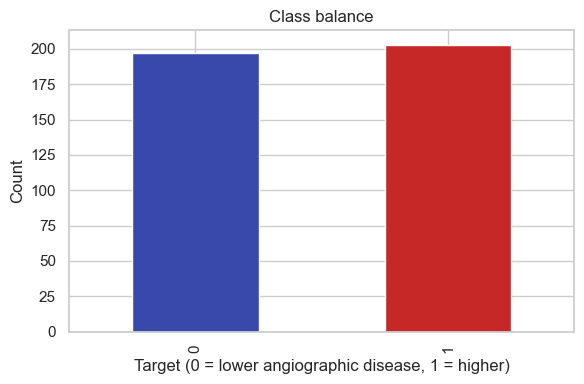

In [15]:
fig, ax = plt.subplots(figsize=(6, 4))
df['target'].value_counts().sort_index().plot(kind='bar', ax=ax, color=['#3949ab', '#c62828'])
ax.set_xlabel('Target (0 = lower angiographic disease, 1 = higher)')
ax.set_ylabel('Count')
ax.set_title('Class balance')
plt.tight_layout()
plt.show()

## 5. Correlation heatmap (numeric features)

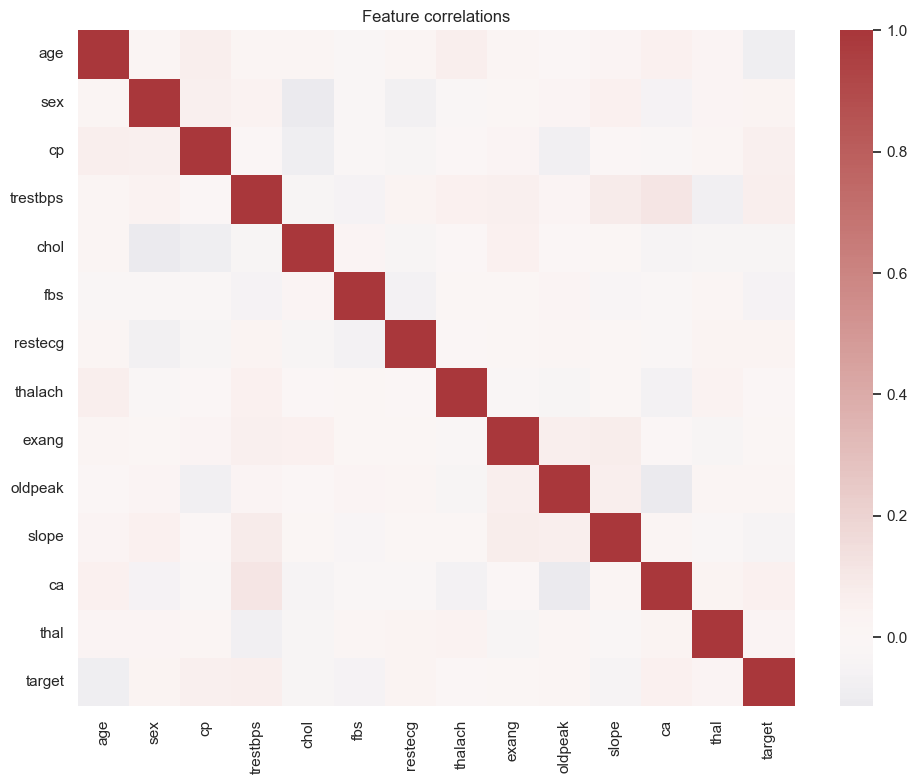

In [16]:
num = df.select_dtypes(include=['number'])
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(num.corr(), cmap='vlag', center=0, ax=ax)
ax.set_title('Feature correlations')
plt.tight_layout()
plt.show()

## 6. Age by target

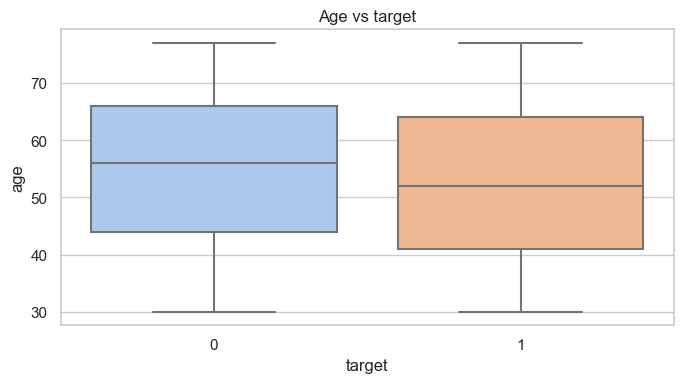

In [17]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=df, x='target', y='age', palette='pastel', ax=ax)
ax.set_title('Age vs target')
plt.tight_layout()
plt.show()

## 7. Random Forest feature importance

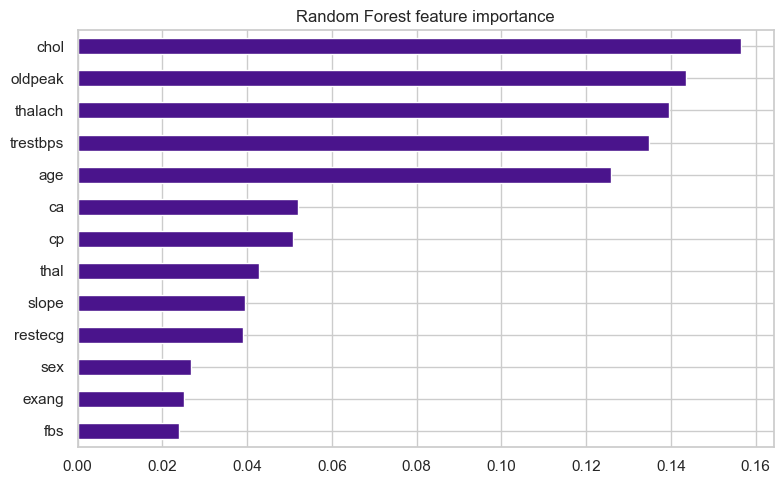

In [18]:
from sklearn.ensemble import RandomForestClassifier
X = df.drop(columns=['target'])
y = df['target']
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X, y)
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(8, 5))
imp.plot(kind='barh', ax=ax, color='#4a148c')
ax.set_title('Random Forest feature importance')
plt.tight_layout()
plt.show()